
# Multi-Scale and Patched Wiener Loss for Autoencoder Reconstruction

This notebook trains a simple Autoencoder on the CIFAR10 dataset using:
1. **Wiener Loss**
2. **Multi-Scale Wiener Loss (MSWienerLoss)**
3. **Patched Wiener Loss**
4. **Mean Squared Error**

We compare their reconstruction performance both quantitatively and qualitatively.


In [ ]:
%load_ext autoreload
%autoreload 2

import os
import glob

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from tqdm import tqdm
import numpy as np

from wiener_loss import WienerLoss, MSWienerLoss, PatchWienerLoss
from utils import set_seed

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:

# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(), 
    # transforms.Grayscale(num_output_channels=1)
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# # subset of dataset for fast prototyping
# train_dataset.data = train_dataset.data[:1000]
# test_dataset.data = test_dataset.data[:1000]

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False) # shuffle false for inspection
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [55]:
# Small Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self, in_channels=1):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, in_channels, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    

# test model output shape
model = Autoencoder(in_channels=train_dataset[0][0].shape[0])
x = torch.randn_like(train_dataset[0][0].unsqueeze(0))  # Example input
output = model(x)
print("Output shape:", output.shape)  
assert output.shape == x.shape, "Output shape does not match input shape!"

Output shape: torch.Size([1, 3, 32, 32])


In [62]:
class EpochCallback:
    def __init__(self, save_dir=None):
        self.count = 0
        self.save_dir = save_dir
        
    def update(self):
        self.count += 1
        return self.count
    
    def reset(self):
        self.count = 0
    
    def __call__(self, model, optimizer, loss_fn, data, output, train_loss):
        # get loss name
        loss_name = type(loss_fn).__name__

        # Create directory if it doesn't exist
        os.makedirs(self.save_dir, exist_ok=True)

        # Save all data in a single file
        save_dict = {
            'data': data,
            'output': output,
            'train_loss': train_loss,
            'model': model,
            'optimizer': optimizer,
            'loss_fn': loss_fn
        }
        torch.save(save_dict, os.path.join(self.save_dir, f"{loss_name}_epoch_{self.count}.pt"))



# Training function for reconstruction
def train_reconstruction(model, loss_fn, optimizer, loader, penalty_optim=None, device='cpu', epoch_callback=None, **kwargs):
    model.train()
    total_loss = 0
    for i, (data, _) in enumerate(loader):
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, data, **kwargs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Update penalty optimizer if provided
        if penalty_optim is not None:
            penalty_optim.zero_grad()
            loss.backward()
            penalty_optim.step()
    
    # Call epoch_callback if provided
    if epoch_callback is not None:
        epoch_callback.update()
        epoch_callback(model, optimizer, loss_fn, data, output, total_loss / len(loader))

    return total_loss / len(loader)





In [63]:
# ############################## INITS ##################################
# # Get useful variables
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# in_channels = train_dataset[0][0].shape[0]  # Number of channels in the input data
# input_shape = train_dataset[0][0].shape  # Shape of the input data (excluding batch size)

# # Set random seed for reproducibility
# set_seed(42)

# # Initialise models
# model_wiener = Autoencoder(in_channels=in_channels).to(device)
# model_mswiener = Autoencoder(in_channels=in_channels).to(device)
# model_patchwiener = Autoencoder(in_channels=in_channels).to(device)
# model_mse = Autoencoder(in_channels=in_channels).to(device)

# # Define a penalty function for the Wiener loss
# def pfn(mesh):
#     return torch.zeros_like(mesh[..., -1]) + 1.

# # Initialise loss functions
# lmbda = 1e-4
# wiener_loss = WienerLoss(input_shape=input_shape, lmbda=lmbda, store_filters=True, penalty_function=pfn, filter_scale=5.)
# ms_wiener_loss = MSWienerLoss(scales=3, input_shape=input_shape, lmbda=lmbda, store_filters=True, penalty_function=pfn, downsample="bilinear")
# patch_wiener_loss = PatchWienerLoss(input_shape=input_shape, lmbda=lmbda, store_filters=True, global_weight=0.5, penalty_function=pfn, patch_size=(8, 8), stride=(4, 4))
# mse_loss = nn.MSELoss()

# # Initialise optimisers for models
# optimizer_wiener = optim.Adam(model_wiener.parameters(), lr=0.001)
# optimizer_mswiener = optim.Adam(model_mswiener.parameters(), lr=0.001)
# optimizer_patchwiener = optim.Adam(model_patchwiener.parameters(), lr=0.001)
# optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.001)

# # Optimisers for penalty functions (PLACEHOLDER)
# optimizer_wiener_penalty = optimizer_mswiener_penalty = optimizer_patchwiener_penalty = None

# # Training and tracking
# epochs = 10
# train_losses_wiener, grad_wiener = [], []
# train_losses_mswiener, grad_mswiener = [], []
# train_losses_patchwiener, grad_patchwiener = [], []
# train_losses_mse, grad_mse = [], []

# # Clear save_dir
# save_dir = "/Users/dp4018/Documents/WienerLoss/examples/wiener_exps"
# if os.path.exists(save_dir):
#     for file in os.listdir(save_dir):
#         os.remove(os.path.join(save_dir, file))

# # Initialise epoch callback objects
# epoch_callbacks = [EpochCallback(save_dir) for i in range(4)]

# ############################### TRAINING #################################

# for epoch in tqdm(range(epochs)):
#     # Train models with different loss functions
#     loss_wiener = train_reconstruction(model_wiener, wiener_loss, optimizer_wiener, train_loader, optimizer_wiener_penalty, device, epoch_callbacks[0], gamma=0.1)
#     loss_mswiener = train_reconstruction(model_mswiener, ms_wiener_loss, optimizer_mswiener, train_loader, optimizer_mswiener_penalty, device, epoch_callbacks[1], gamma=0.1)
#     loss_patchwiener = train_reconstruction(model_patchwiener, patch_wiener_loss, optimizer_patchwiener, train_loader, optimizer_patchwiener_penalty, device, epoch_callbacks[2], gamma=0.1)
#     loss_mse = train_reconstruction(model_mse, mse_loss, optimizer_mse, train_loader, None, device, epoch_callbacks[3])

#     # Append losses to tracking lists
#     train_losses_wiener.append(loss_wiener)
#     train_losses_mswiener.append(loss_mswiener)
#     train_losses_patchwiener.append(loss_patchwiener)
#     train_losses_mse.append(loss_mse)

#     # Track average model gradients
#     grad_wiener.append(torch.mean(torch.stack([torch.norm(p.grad) for p in model_wiener.parameters() if p.grad is not None])).item())
#     grad_mswiener.append(torch.mean(torch.stack([torch.norm(p.grad) for p in model_mswiener.parameters() if p.grad is not None])).item())
#     grad_patchwiener.append(torch.mean(torch.stack([torch.norm(p.grad) for p in model_patchwiener.parameters() if p.grad is not None])).item())
#     grad_mse.append(torch.mean(torch.stack([torch.norm(p.grad) for p in model_mse.parameters() if p.grad is not None])).item())

    
# ############################### PLOTTING #################################
# # Plot training losses in subplots
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# axes[0, 0].plot(train_losses_wiener, label='Wiener Loss', color='tab:blue')
# axes[0, 0].set_title('Wiener Loss')
# axes[0, 0].set_xlabel('Epoch')
# axes[0, 0].set_ylabel('Training Loss')

# axes[0, 1].plot(train_losses_mswiener, label='MS-Wiener Loss', color='tab:orange')
# axes[0, 1].set_title('MS-Wiener Loss')
# axes[0, 1].set_xlabel('Epoch')
# axes[0, 1].set_ylabel('Training Loss')

# axes[1, 0].plot(train_losses_patchwiener, label='Patch-Wiener Loss', color='tab:green')
# axes[1, 0].set_title('Patch-Wiener Loss')
# axes[1, 0].set_xlabel('Epoch')
# axes[1, 0].set_ylabel('Training Loss')

# axes[1, 1].plot(train_losses_mse, label='MSE Loss', color='tab:red')
# axes[1, 1].set_title('MSE Loss')
# axes[1, 1].set_xlabel('Epoch')
# axes[1, 1].set_ylabel('Training Loss')

# for ax in axes.flat:
#     ax.legend()
#     ax.grid(True)

# plt.tight_layout()
# plt.show()


# # Plot average model gradients in subplots
# fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes[0, 0].plot(grad_wiener, label='Wiener Loss Gradients', color='tab:blue')
# axes[0, 0].set_title('Wiener Loss Gradients')
# axes[0, 0].set_xlabel('Epoch')
# axes[0, 0].set_ylabel('Average Gradient Norm')
# axes[0, 1].plot(grad_mswiener, label='MS-Wiener Loss Gradients', color='tab:orange')
# axes[0, 1].set_title('MS-Wiener Loss Gradients')
# axes[0, 1].set_xlabel('Epoch')
# axes[0, 1].set_ylabel('Average Gradient Norm')
# axes[1, 0].plot(grad_patchwiener, label='Patch-Wiener Loss Gradients', color='tab:green')
# axes[1, 0].set_title('Patch-Wiener Loss Gradients')
# axes[1, 0].set_xlabel('Epoch')
# axes[1, 0].set_ylabel('Average Gradient Norm')
# axes[1, 1].plot(grad_mse, label='MSE Loss Gradients', color='tab:red')
# axes[1, 1].set_title('MSE Loss Gradients')
# axes[1, 1].set_xlabel('Epoch')
# axes[1, 1].set_ylabel('Average Gradient Norm')
# for ax in axes.flat:
#     ax.legend()
#     ax.grid(True)
# plt.tight_layout()
# plt.show()



  0%|          | 0/10 [00:00<?, ?it/s]

 90%|█████████ | 9/10 [2:20:41<15:37, 937.93s/it]  


KeyboardInterrupt: 

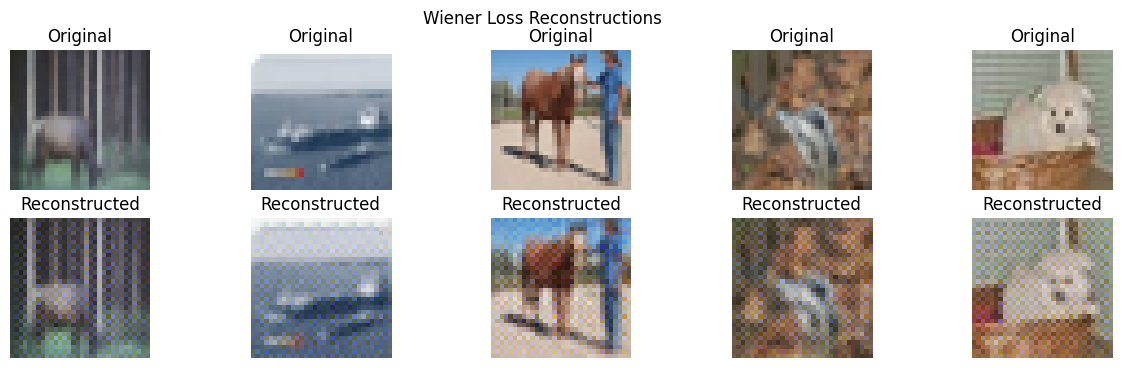

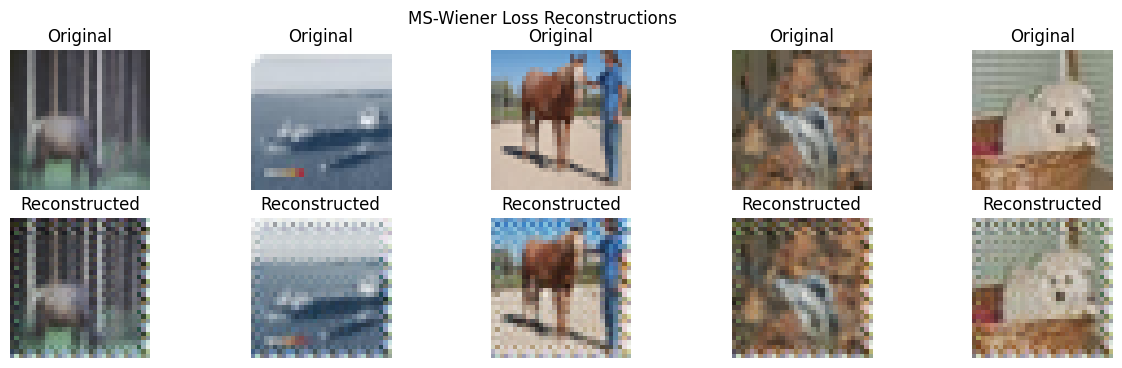

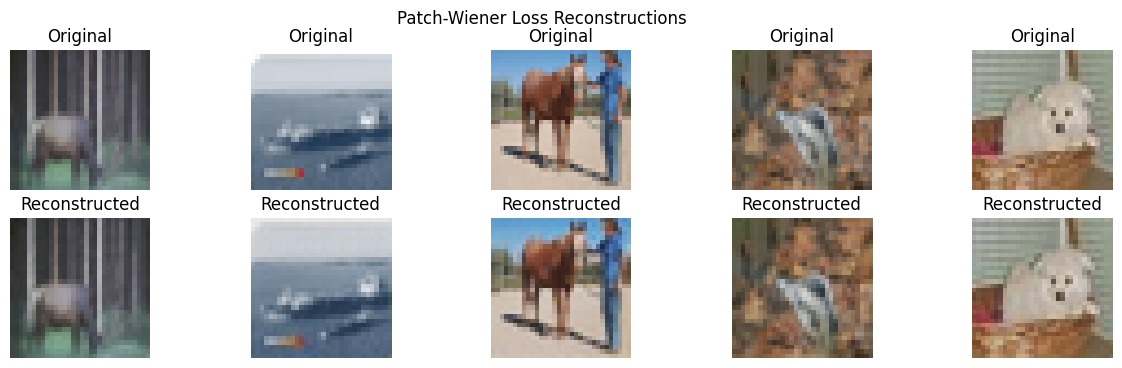

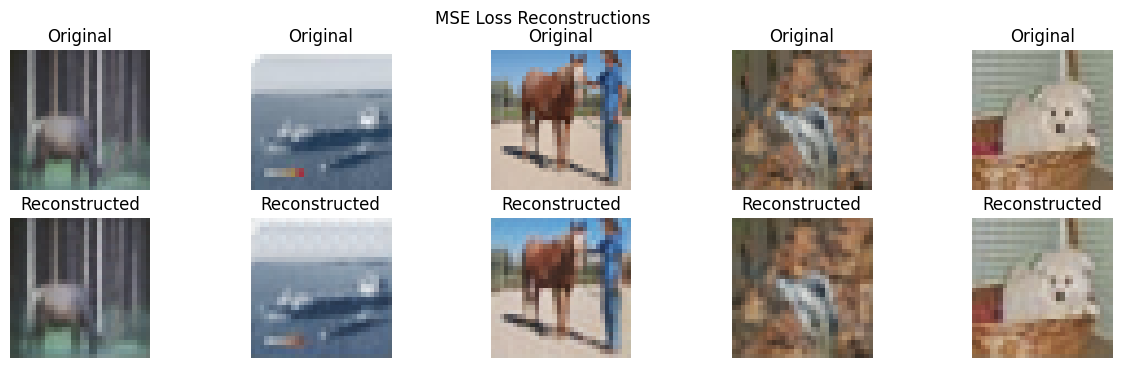

In [64]:
# Visualise model reconstructions
def visualize_reconstructions(model, loader, device, num_images=5, title='Reconstruction'):
    model.eval()
    data_iter = iter(loader)

    # Get the last batch by iterating through all batches
    # images, _ = None
    for batch in data_iter:
        images, _ = batch
    images = images.to(device)
    
    with torch.no_grad():
        outputs = model(images)
    
    fig, axes = plt.subplots(2, num_images, figsize=(15, 4))
    for i in range(num_images):
        axes[0, i].imshow(images[i].permute(1, 2, 0).cpu().squeeze(), cmap='gray')
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        axes[1, i].imshow(outputs[i].permute(1, 2, 0).cpu().squeeze(), cmap='gray')
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')
    
    plt.suptitle(title)
    plt.show()

# Visualize reconstructions for both models
visualize_reconstructions(model_wiener, train_loader, device, title='Wiener Loss Reconstructions')
visualize_reconstructions(model_mswiener, train_loader, device, title='MS-Wiener Loss Reconstructions')
visualize_reconstructions(model_patchwiener, train_loader, device, title='Patch-Wiener Loss Reconstructions')
visualize_reconstructions(model_mse, train_loader, device, title='MSE Loss Reconstructions')

In [65]:
def animate_reconstructions(loss_name, root):
    """
    Create an animation showing the progression of reconstructions across epochs for a given loss function
    
    Args:
        loss_name (str): Name of the loss function ('wiener', 'mswiener', 'patchwiener', or 'mse')
    """

    
    # Get list of all epoch files for this loss
    files = sorted(glob.glob(f'{root}/{loss_name}_epoch_*.pt'),
                  key=lambda x: int(x.split('epoch_')[1].split('.')[0]))
    
    if len(files) == 0:
        print(f"No saved epochs found for {loss_name}")
        return
        
    # Load first epoch to get image dimensions
    first_epoch = torch.load(files[0], weights_only=False)
    inputs = first_epoch['data']
    num_images = min(5, inputs.shape[0])
    
    # Create figure
    fig, axes = plt.subplots(2, num_images, figsize=(15, 4))
    plt.suptitle(f'{loss_name} Loss Reconstruction Progress')
    
    # Plot original images (these stay constant)
    for i in range(num_images):
        axes[0, i].imshow(inputs[i].permute(1, 2, 0).cpu().squeeze(), cmap='gray')
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')
    
    def update(frame):
        # Load epoch data
        epoch_data = torch.load(files[frame], weights_only=False)
        outputs = epoch_data['output']
        
        # Update reconstructed images
        for i in range(num_images):
            axes[1, i].clear()
            axes[1, i].imshow(outputs[i].permute(1, 2, 0).detach().cpu().squeeze(), cmap='gray')
            axes[1, i].set_title(f"Epoch {frame}")
            axes[1, i].axis('off')
        return axes.flat
    
    anim = FuncAnimation(fig, update, frames=len(files), 
                        interval=400, blit=True)
    plt.close()
    return anim

# Create animations for each loss function
for loss in ['WienerLoss', 'MSWienerLoss', 'PatchWienerLoss', 'MSELoss']:
    anim = animate_reconstructions(loss, save_dir)
    if anim is not None:
        # from IPython.display import HTML
        # HTML(anim.to_jshtml())
        output_path = os.path.join(save_dir, f"{loss}_reconstruction.gif")
        anim.save(output_path, writer='pillow')
        print(f"Saved animation to {output_path}")


Saved animation to /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/WienerLoss_reconstruction.gif
Saved animation to /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/MSWienerLoss_reconstruction.gif
Saved animation to /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/PatchWienerLoss_reconstruction.gif
Saved animation to /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/MSELoss_reconstruction.gif


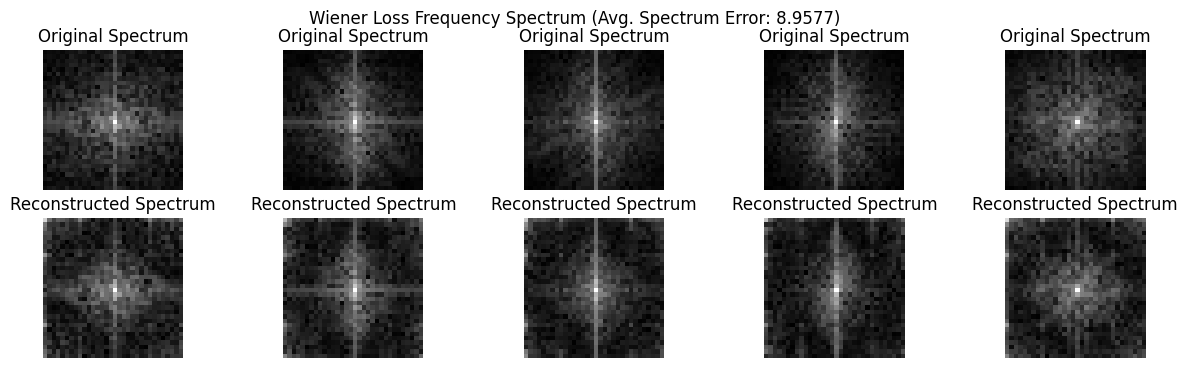

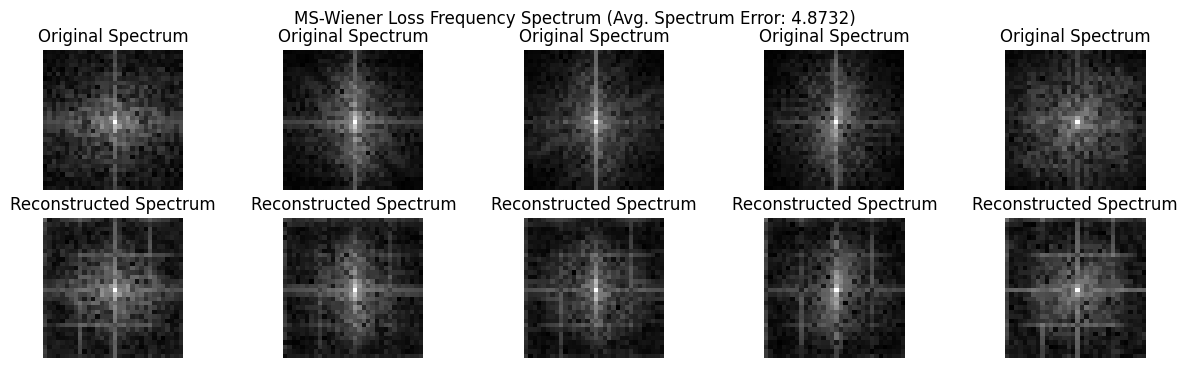

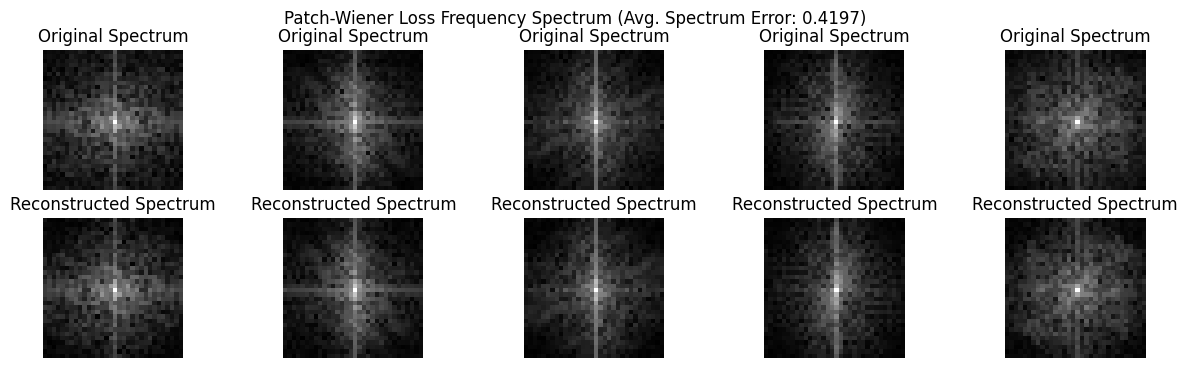

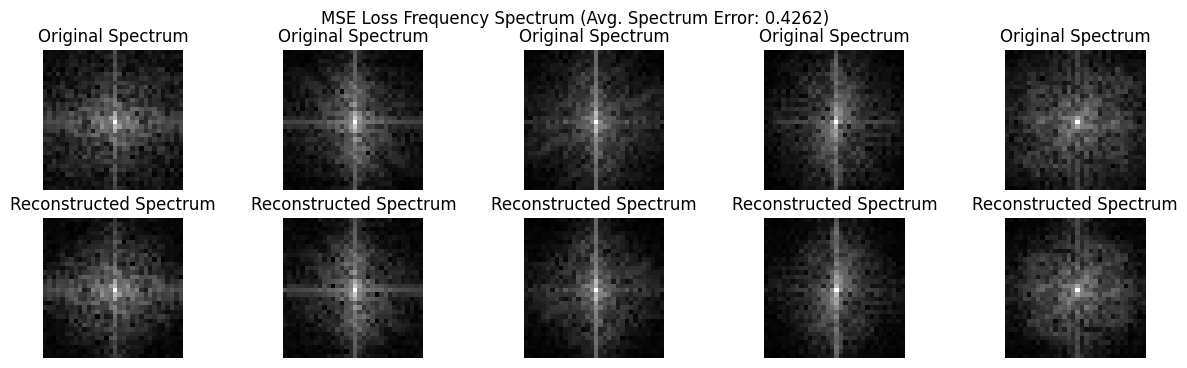

In [66]:
def visualize_frequency_spectra(model, loader, device, num_images=5, title='Frequency Spectrum'):
    """
    Visualize frequency spectra (magnitude of FFT) of original and reconstructed images.

    Args:
        model: PyTorch model for reconstruction.
        loader: DataLoader with input images.
        device: torch.device.
        num_images: Number of images to visualise.
        title: Title for the plot.
    """
    model.eval()
    data_iter = iter(loader)
    images, _ = next(data_iter)
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)#[:, 0, :, :].unsqueeze(1)  # Analyse only the first channel
        # images = images[:, 0, :, :].unsqueeze(1) # Analyse only the first channel

    fig, axes = plt.subplots(2, num_images, figsize=(15, 4))

    spectrum_error = 0.

    for i in range(num_images):
        original = images[i].cpu().squeeze().numpy()
        reconstructed = outputs[i].cpu().squeeze().numpy()

        # Compute magnitude spectrum
        orig_fft = np.abs(np.fft.fftshift(np.fft.fft2(original)))
        recon_fft = np.abs(np.fft.fftshift(np.fft.fft2(reconstructed)))

        # Compute average spectrum error
        spectrum_error += np.mean((orig_fft - recon_fft)**2)

        # Log scale for better visibility
        orig_fft_log = np.log1p(orig_fft)
        recon_fft_log = np.log1p(recon_fft)

        axes[0, i].imshow(orig_fft_log[0], cmap='gray') # analyse only the first channel
        axes[0, i].set_title("Original Spectrum")
        axes[0, i].axis('off')

        axes[1, i].imshow(recon_fft_log[0], cmap='gray') # analyse only the first channel
        axes[1, i].set_title("Reconstructed Spectrum")
        axes[1, i].axis('off')

    # Compute average spectrum error
    spectrum_error /= num_images

    plt.suptitle(title + f' (Avg. Spectrum Error: {spectrum_error:.4f})')
    plt.show()

visualize_frequency_spectra(model_wiener, test_loader, device, title='Wiener Loss Frequency Spectrum')
visualize_frequency_spectra(model_mswiener, test_loader, device, title='MS-Wiener Loss Frequency Spectrum')
visualize_frequency_spectra(model_patchwiener, test_loader, device, title='Patch-Wiener Loss Frequency Spectrum')
visualize_frequency_spectra(model_mse, test_loader, device, title='MSE Loss Frequency Spectrum')

/opt/homebrew/Caskroom/miniconda/base/envs/wiener/lib/python3.10/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


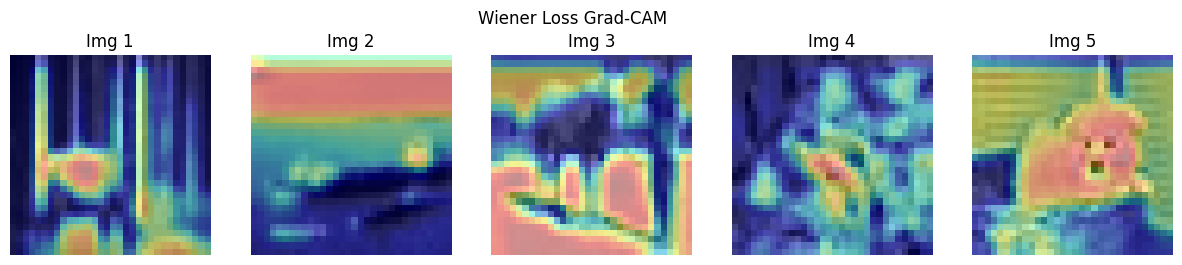

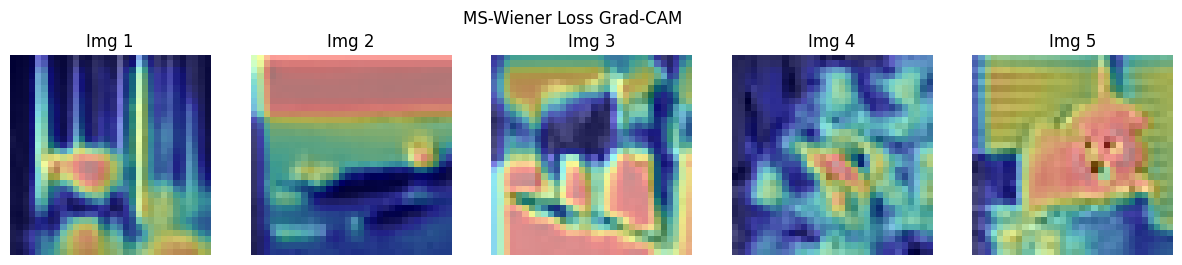

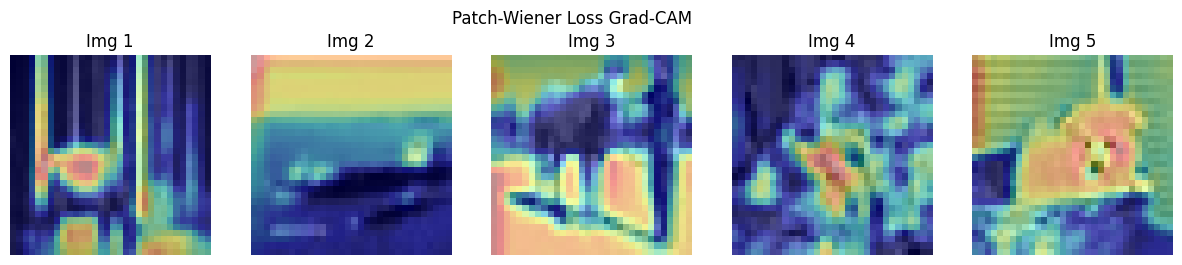

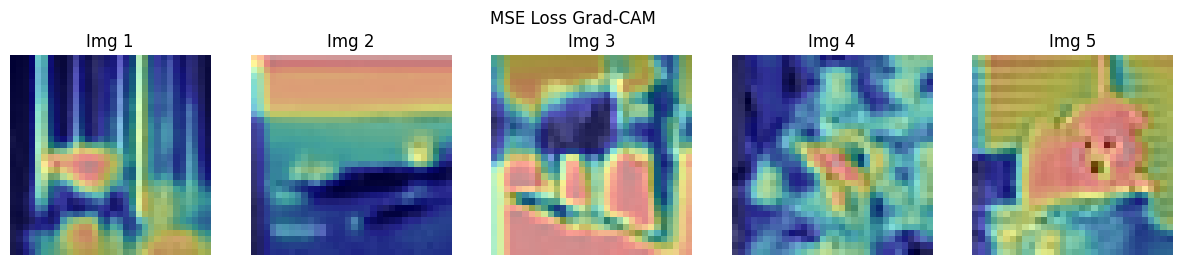

In [67]:
def compute_gradcam(model, input_image, target_layer):
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
    
    def forward_hook(module, input, output):
        activations.append(output)
    
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)
    
    input_image = input_image.unsqueeze(0).to(next(model.parameters()).device).requires_grad_(True)
    output = model(input_image)
    loss = output.sum()
    model.zero_grad()
    loss.backward()
    
    grads = gradients[0].cpu().data
    acts = activations[0].cpu().data
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=input_image.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam.squeeze().numpy()
    
    handle_f.remove()
    handle_b.remove()
    
    return cam

def plot_gradcam_batch(model, loader, target_layer, device, title="Grad-CAM", num_images=5):
    """
    Plots Grad-CAM for multiple images in a batch.

    Args:
        model: PyTorch model.
        loader: DataLoader.
        target_layer: Layer to compute Grad-CAM on.
        device: torch.device.
        title: Title for the figure.
        num_images: Number of images to plot from the batch.
    """
    data_iter = iter(loader)
    for batch in data_iter:
        images, _ = batch
    images = images.to(device)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    
    for idx in range(num_images):
        image = images[idx]
        cam = compute_gradcam(model, image, target_layer)

        axes[idx].imshow(image.cpu().squeeze()[0], cmap='gray')
        axes[idx].imshow(cam, cmap='jet', alpha=0.4)
        axes[idx].set_title(f"Img {idx+1}")
        axes[idx].axis('off')
    
    plt.suptitle(title)
    plt.show()

# Plot Grad-CAM for both models using the first conv layer in encoder
plot_gradcam_batch(model_wiener, train_loader, model_wiener.encoder[0], device, title="Wiener Loss Grad-CAM")
plot_gradcam_batch(model_mswiener, train_loader, model_mswiener.encoder[0], device, title="MS-Wiener Loss Grad-CAM")
plot_gradcam_batch(model_patchwiener, train_loader, model_patchwiener.encoder[0], device, title="Patch-Wiener Loss Grad-CAM")
plot_gradcam_batch(model_mse, train_loader, model_mse.encoder[0], device, title="MSE Loss Grad-CAM")


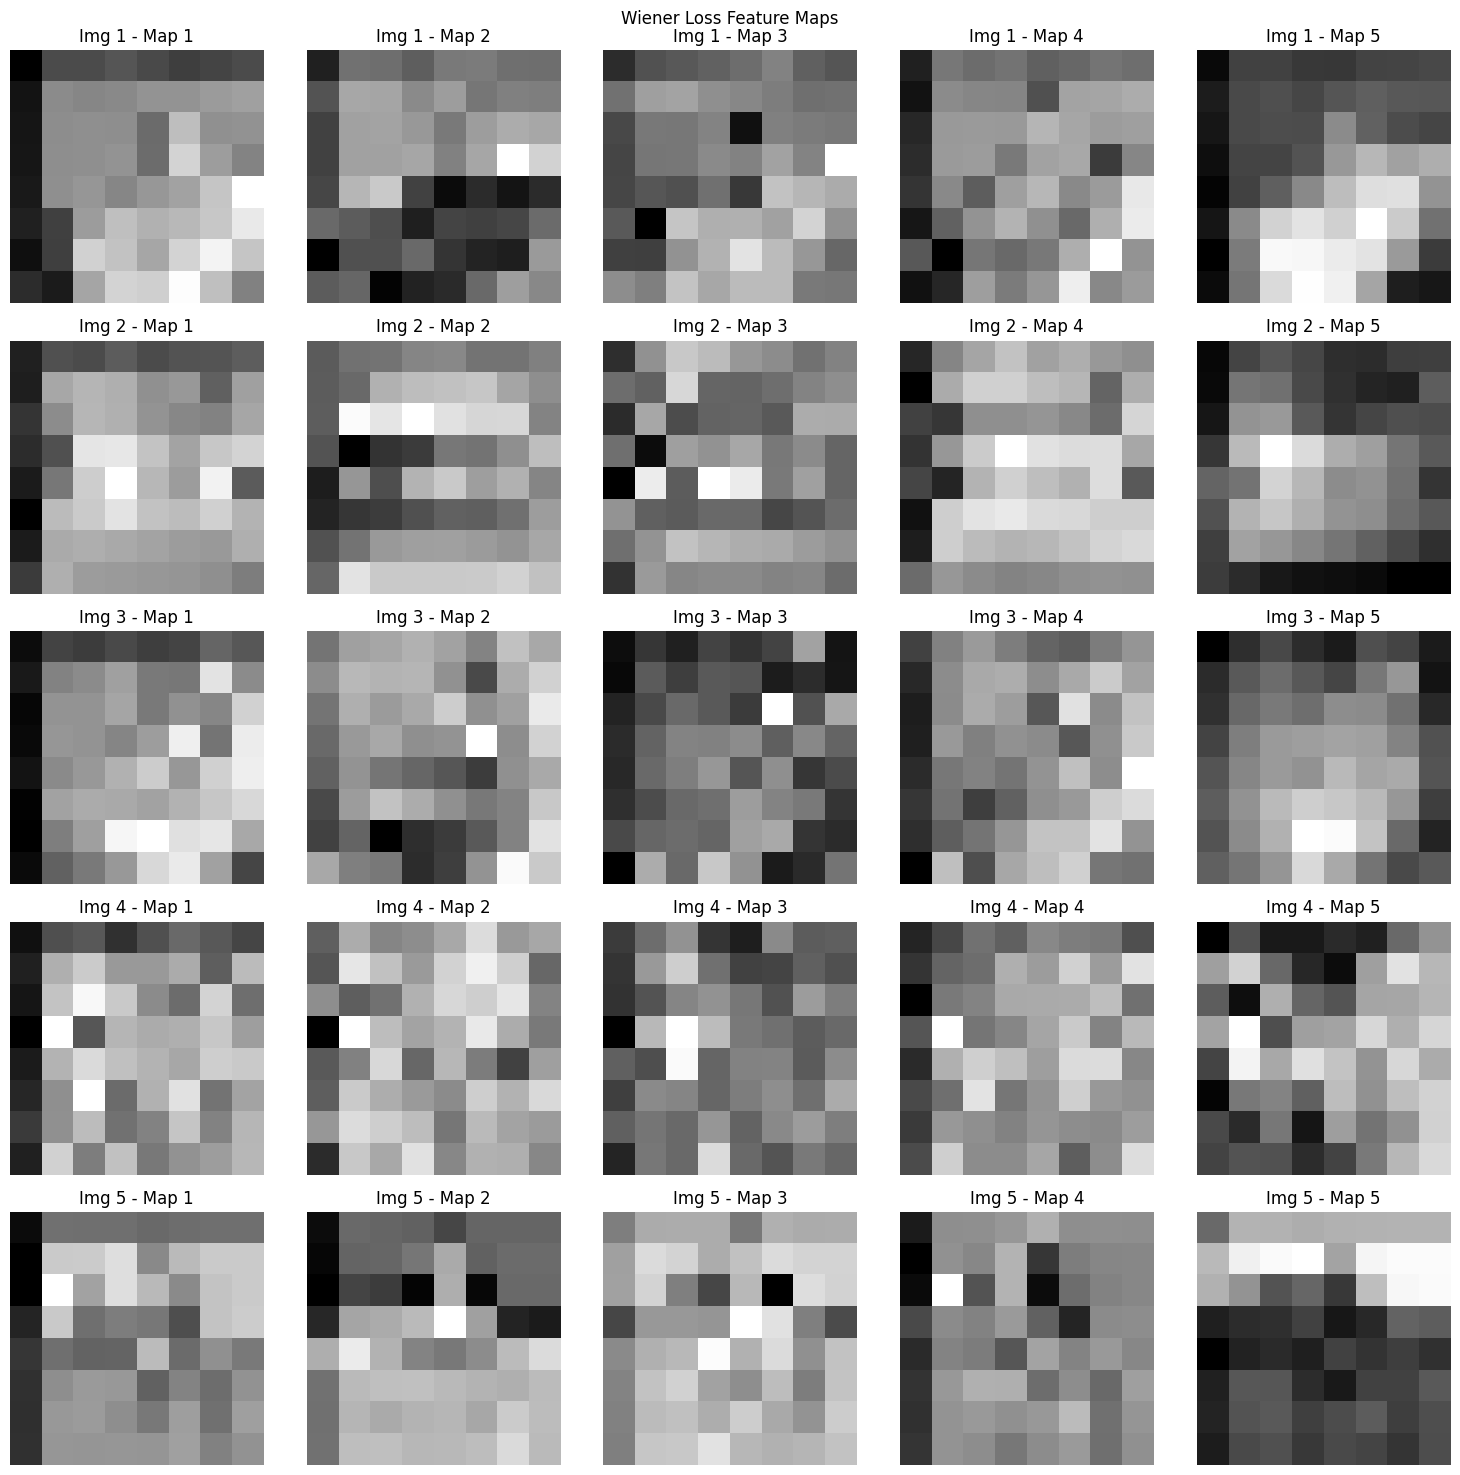

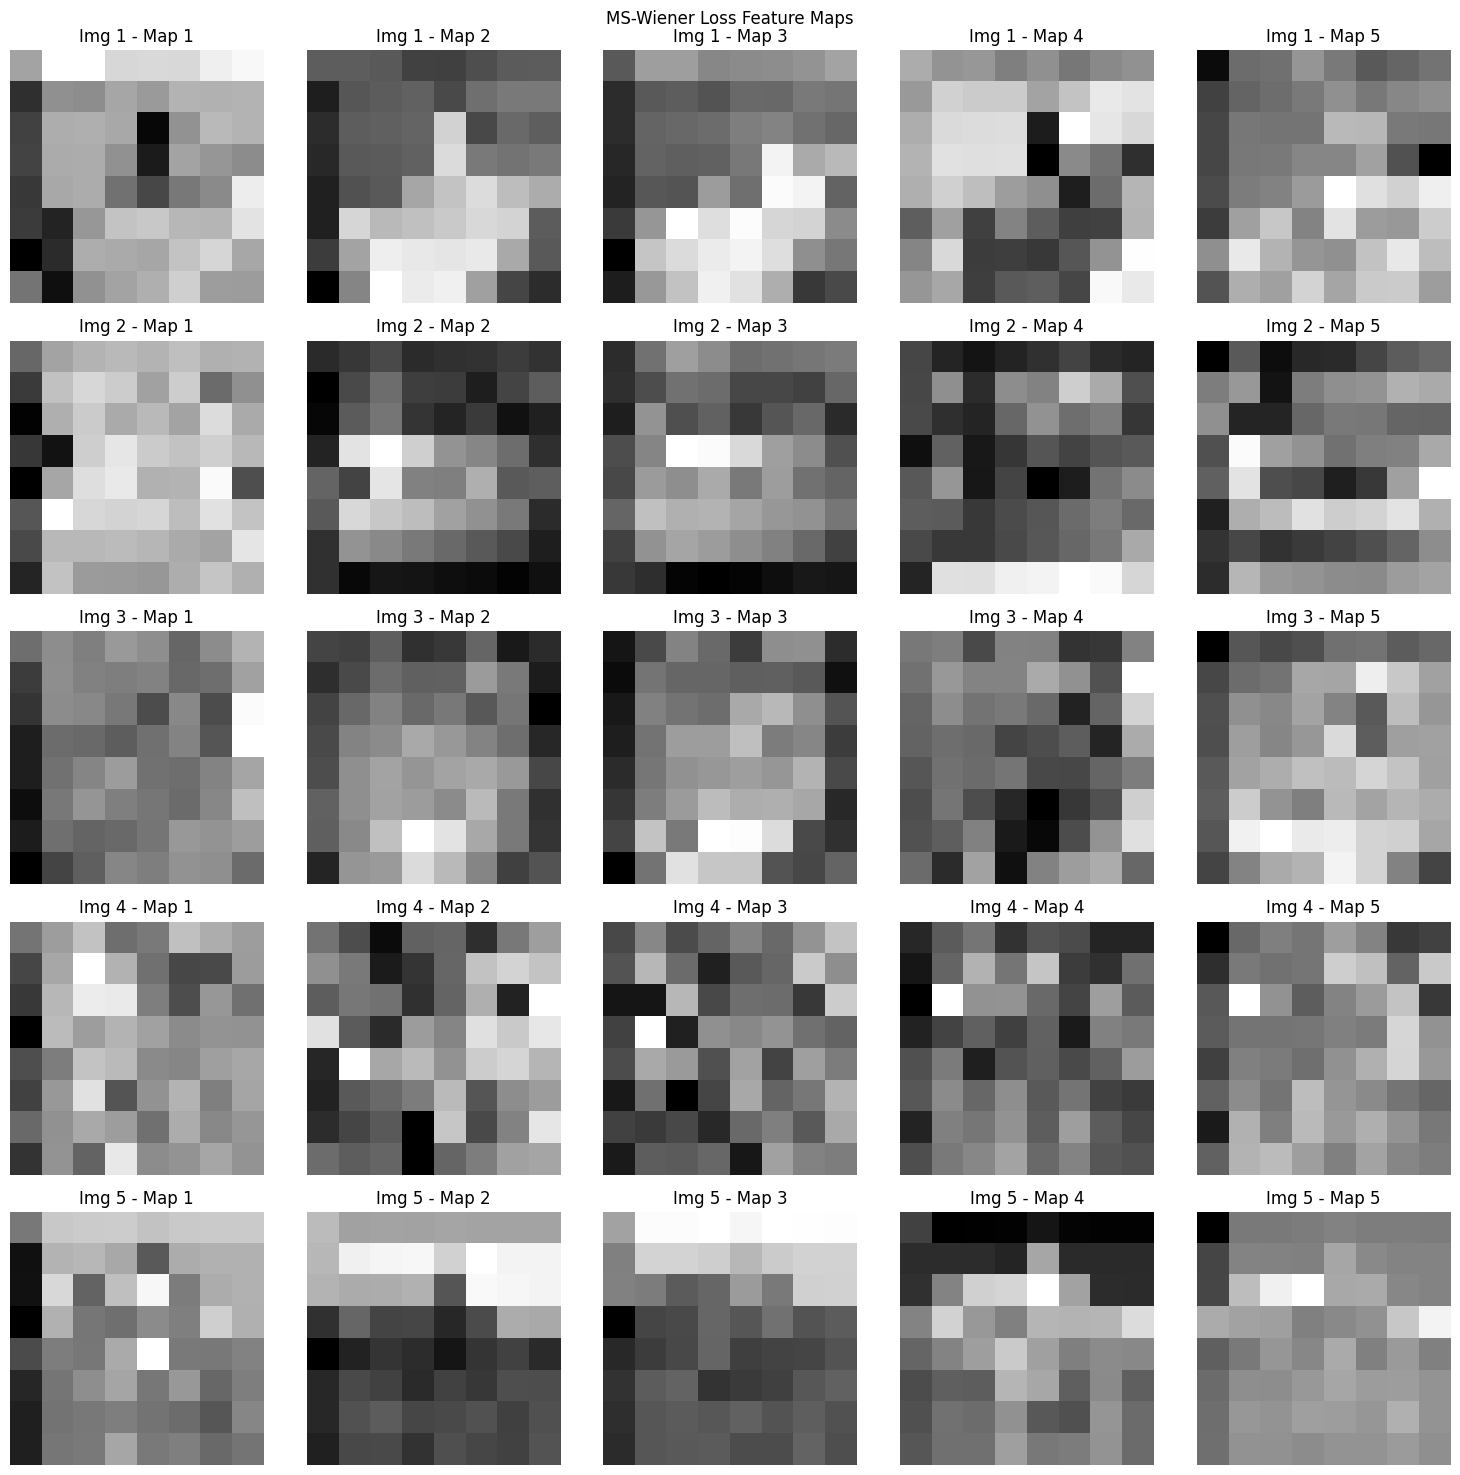

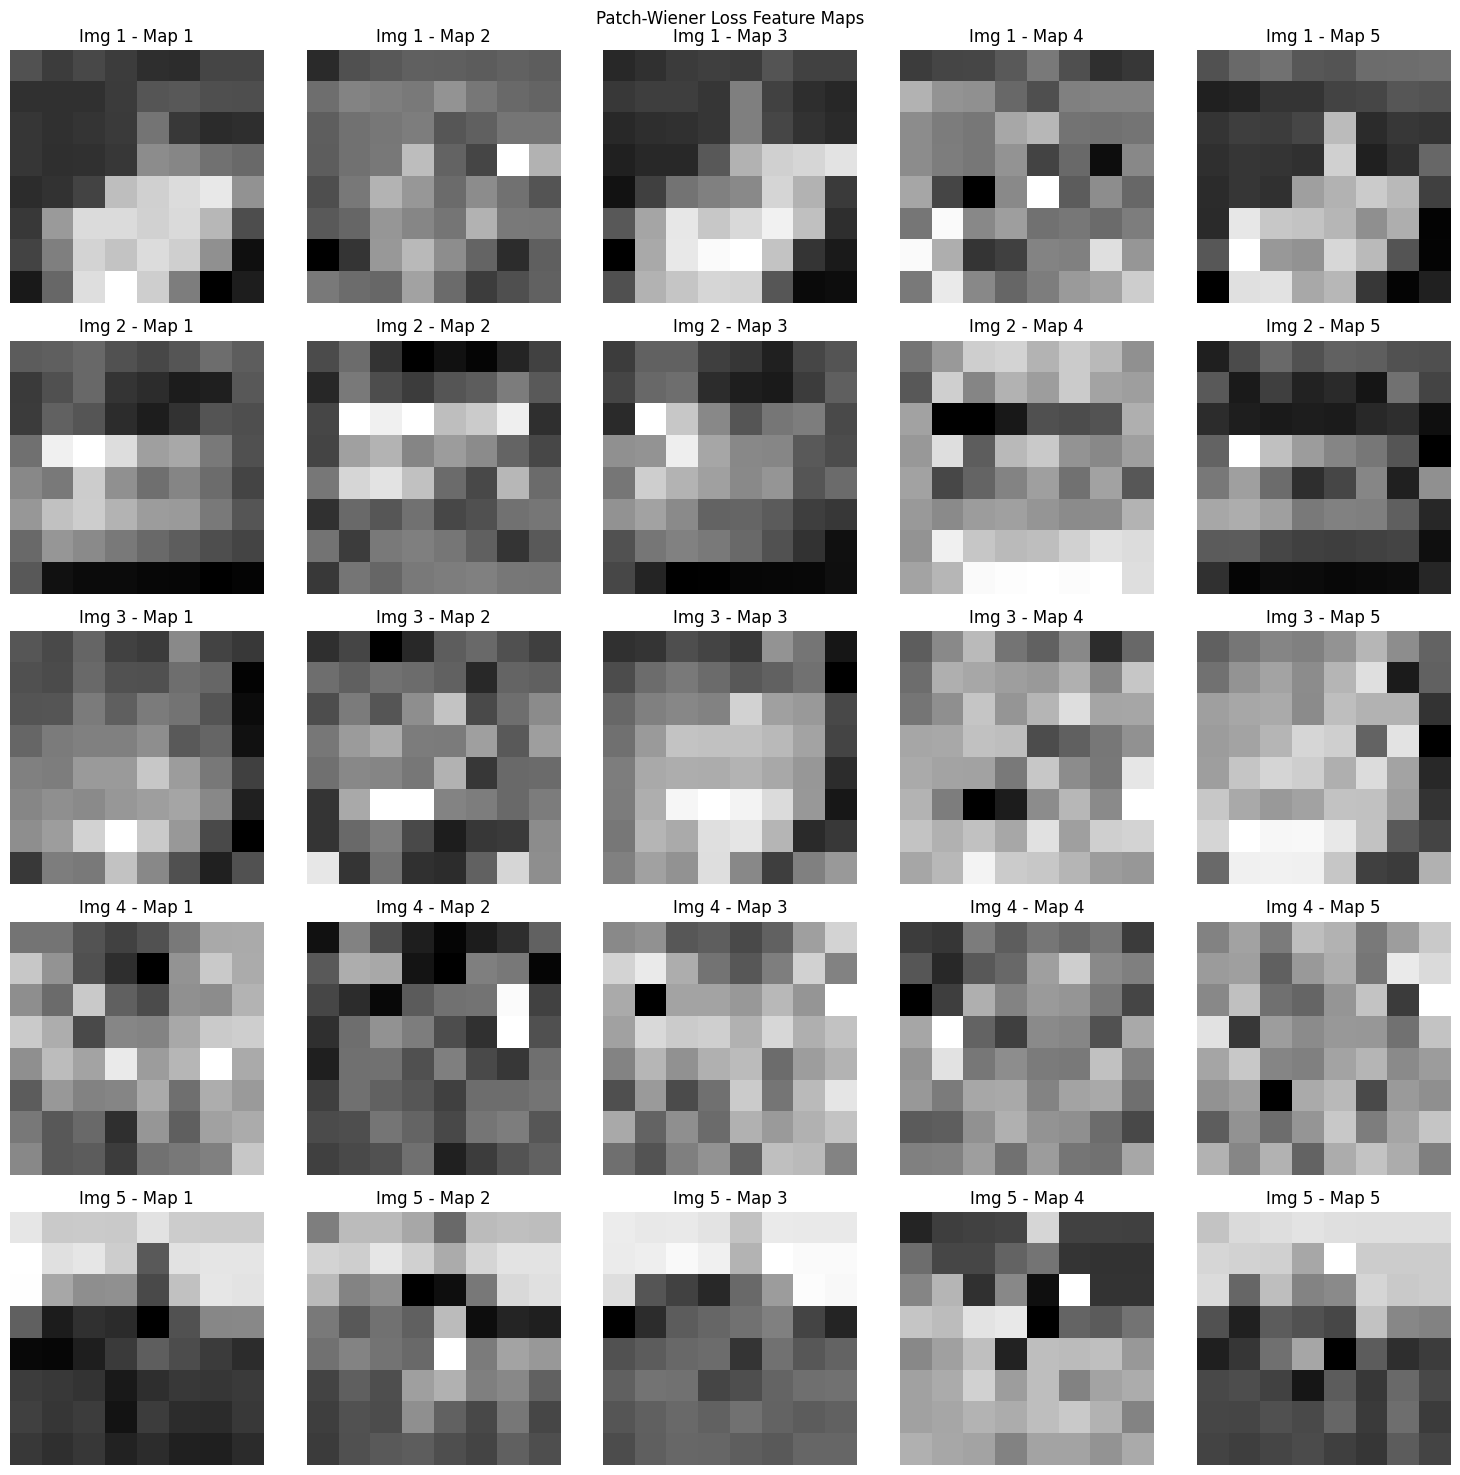

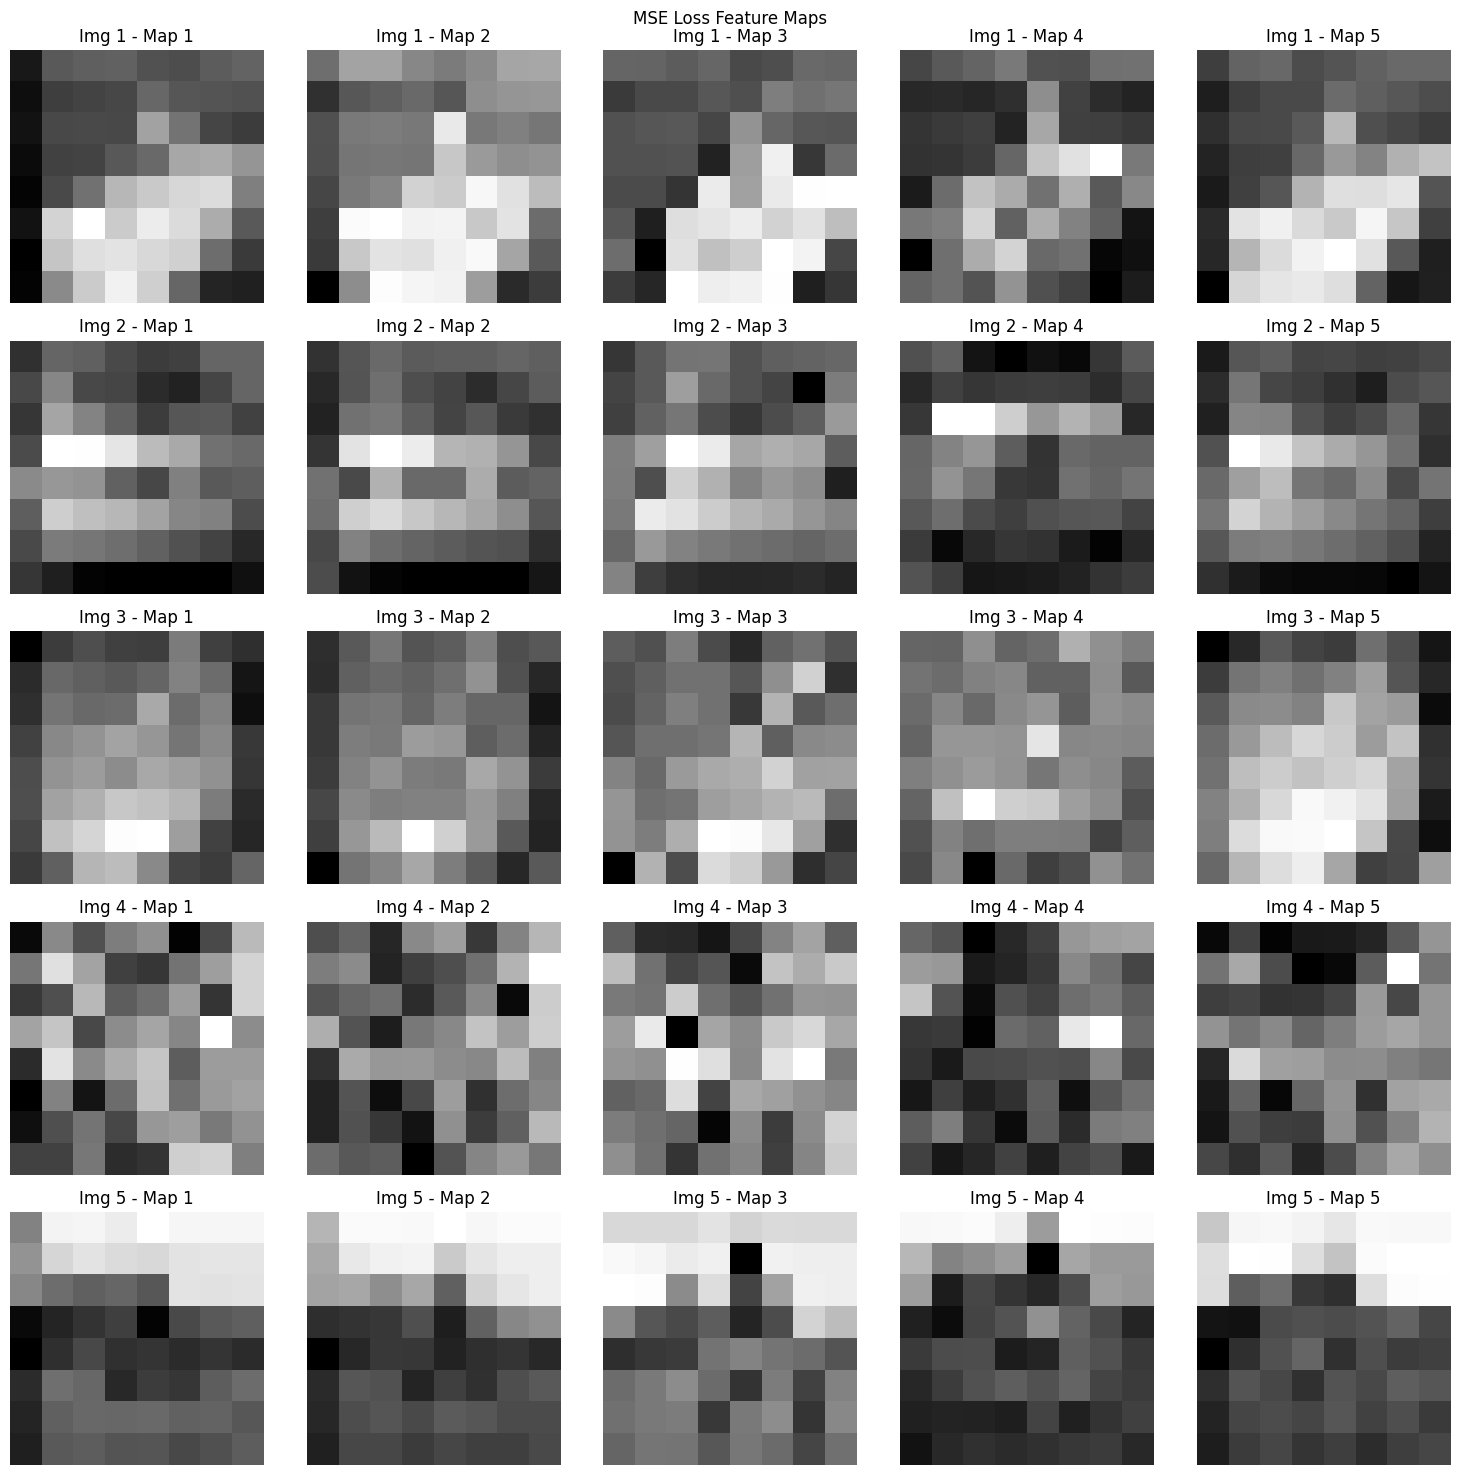

In [68]:
def plot_feature_maps_batch(model, loader, device, num_maps=5, num_images=5, title='Feature Maps'):
    """
    Plots feature maps for multiple images in a batch.

    Args:
        model: PyTorch model.
        loader: DataLoader.
        device: torch.device.
        num_maps: Number of feature maps to plot per image.
        num_images: Number of images from the batch to plot.
        title: Title for the figure.
    """
    data_iter = iter(loader)
    for batch in data_iter:
        images, _ = batch
    images = images.to(device)

    model.eval()
    with torch.no_grad():
        features = model.encoder(images)
    
    fig, axes = plt.subplots(num_images, num_maps, figsize=(3*num_maps, 3*num_images))

    for img_idx in range(num_images):
        for map_idx in range(num_maps):
            ax = axes[img_idx, map_idx] if num_images > 1 else axes[map_idx]
            ax.imshow(features[img_idx, map_idx].cpu().numpy(), cmap='gray')
            ax.set_title(f"Img {img_idx+1} - Map {map_idx+1}")
            ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Plot feature maps for both models
plot_feature_maps_batch(model_wiener, test_loader, device, title="Wiener Loss Feature Maps")
plot_feature_maps_batch(model_mswiener, test_loader, device, title="MS-Wiener Loss Feature Maps")
plot_feature_maps_batch(model_patchwiener, test_loader, device, title="Patch-Wiener Loss Feature Maps")
plot_feature_maps_batch(model_mse, test_loader, device, title="MSE Loss Feature Maps")


In [20]:
from landscape import visualise_landscape

# subset of train_loader for fast prototyping
train_dataset_vis = torch.utils.data.Subset(train_loader.dataset, range(1000))
train_loader_vis = DataLoader(train_dataset_vis, batch_size=64, shuffle=False)

nx = ny = 25

_ = visualise_landscape(model_wiener, train_loader_vis, wiener_loss, nx=nx, ny=ny, device=device)

_ = visualise_landscape(model_mswiener, train_loader_vis, ms_wiener_loss, nx=nx, ny=ny, device=device)

_ = visualise_landscape(model_patchwiener, train_loader_vis, patch_wiener_loss, nx=nx, ny=ny, device=device)

_ = visualise_landscape(model_mse, train_loader_vis, mse_loss, nx=nx, ny=ny, device=device)


Angle between x_dir and y_dir: 90.52 °


0it [00:16, ?it/s]


KeyboardInterrupt: 